# 🛒 Рекомендательная система товаров в электронной коммерции

## 📌 Описание проекта

Электронная коммерция является одной из ключевых областей применения рекомендательных систем. Такие системы позволяют пользователям быстрее находить интересующие их товары, а бизнесу — увеличивать вовлечённость и выручку.

В рамках данного проекта решается задача:

> **предсказания товаров, которые с наибольшей вероятностью будут добавлены пользователем в корзину**

Рекомендации строятся на основе пользовательских взаимодействий:

* просмотры (`view`)
* добавления в корзину (`addtocart`)
* покупки (`transaction`)

---

## 🎯 Цель проекта

Разработать рекомендательную систему, которая:

* предсказывает товары, интересные пользователю
* учитывает историю взаимодействий
* работает в условиях разреженных данных
* обрабатывает cold start
* может быть развернута как веб-сервис

---

## 🧠 Постановка задачи

Задача формулируется как:

> **ranking / recommendation задача с implicit feedback**

Особенности:

* неявная обратная связь (implicit)
* дисбаланс событий (`view >> addtocart >> transaction`)
* временная структура данных
* высокая разреженность user-item матрицы

---

## 📊 Данные

Датасет состоит из трёх источников:

### 1. `events.csv`

Лог пользовательских событий:

* `timestamp` — время события
* `visitorid` — пользователь
* `event` — тип события (`view`, `addtocart`, `transaction`)
* `itemid` — товар
* `transactionid` — id покупки

---

### 2. `category_tree.csv`

* `categoryid` — категория
* `parentid` — родительская категория

---

### 3. `item_properties`

Файл разбит на две части:

* `item_properties_part1.csv`
* `item_properties_part2.csv`

Содержит:

* `timestamp`
* `itemid`
* `property`
* `value`


# 1. Импорты

In [1]:
# Стандартная библиотека
import gc
import logging
import os
import pickle
import sys
import warnings
from collections import defaultdict
from pathlib import Path
from typing import List, Tuple
import os
import sys
import warnings

import pandas as pd

# Работа с данными
import numpy as np
import pandas as pd

# Визуализация
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from plotly.subplots import make_subplots

# Статистика
from scipy.sparse import csr_matrix
from scipy.stats import gaussian_kde

# ML
import lightgbm as lgb
from implicit.als import AlternatingLeastSquares
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Файлы и хранилища
import boto3
import pyarrow as pa
import pyarrow.parquet as pq
import s3fs
from dotenv import load_dotenv

# Прочее
import phik
from phik import report, resources
from tqdm.auto import tqdm

In [2]:
# настройки отображения
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 300)
pd.options.display.float_format = "{:,.0f}".format

# настройки графиков
%matplotlib inline
%config InlineBackend.figure_format = "retina"

# корень проекта
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("PROJECT_ROOT:", os.path.basename(PROJECT_ROOT))
print("src exists:", os.path.isdir(os.path.join(PROJECT_ROOT, "src")))

def to_relative(path, base):
    try:
        return os.path.relpath(path, base)
    except ValueError:
        return path

from src.utils.config import (
    DATA_DIR,
    RAW_DIR,
    PROCESSED_DIR,
    EVENTS_PATH,
    CATEGORY_TREE_PATH,
    ITEM_PROPERTIES_PATH,
    ARTIFACTS_DIR,
    MODELS_DIR,
    MLFLOW_BASE_DIR,
    MLFLOW_DIR,
    MLFLOW_DB_PATH,
    AIRFLOW_DIR,
    AIRFLOW_DAGS_DIR,
)

# S3
S3_BASE = "s3://s3-student-mle-20250927-31ecef0a74/recsys"
S3_DATA_DIR = f"{S3_BASE}/data"
S3_REC_DIR = f"{S3_BASE}/recommendations"

# проверка путей
paths_to_check = {
    "DATA_DIR": DATA_DIR,
    "RAW_DIR": RAW_DIR,
    "PROCESSED_DIR": PROCESSED_DIR,
    "ARTIFACTS_DIR": ARTIFACTS_DIR,
    "MODELS_DIR": MODELS_DIR,
    "MLFLOW_BASE_DIR": MLFLOW_BASE_DIR,
    "MLFLOW_DIR": MLFLOW_DIR,
    "MLFLOW_DB_PATH": MLFLOW_DB_PATH,
    "AIRFLOW_DIR": AIRFLOW_DIR,
    "AIRFLOW_DAGS_DIR": AIRFLOW_DAGS_DIR,
    "EVENTS_PATH": EVENTS_PATH,
    "CATEGORY_TREE_PATH": CATEGORY_TREE_PATH,
    "ITEM_PROPERTIES_PATH": ITEM_PROPERTIES_PATH,
}

print("\nProject paths:\n")

for name, path in paths_to_check.items():
    rel_path = to_relative(path, PROJECT_ROOT)
    status = "OK" if os.path.exists(path) else "MISSING"
    print(f"{name:<22} {rel_path:<40} [{status}]")

PROJECT_ROOT: ecommerce-recsys
src exists: True

Project paths:

DATA_DIR               data                                     [OK]
RAW_DIR                data/raw                                 [OK]
PROCESSED_DIR          data/processed                           [OK]
ARTIFACTS_DIR          artifacts                                [OK]
MODELS_DIR             artifacts/models                         [OK]
MLFLOW_BASE_DIR        mlflow                                   [OK]
MLFLOW_DIR             mlflow/mlruns                            [OK]
MLFLOW_DB_PATH         mlflow/mlflow.db                         [MISSING]
AIRFLOW_DIR            airflow                                  [OK]
AIRFLOW_DAGS_DIR       airflow/dags                             [OK]
EVENTS_PATH            data/raw/events.csv                      [OK]
CATEGORY_TREE_PATH     data/raw/category_tree.csv               [OK]
ITEM_PROPERTIES_PATH   data/raw/item_properties.csv             [MISSING]


# === ЭТАП 1 ===

# 2. Загрузка первичных данных

Загружаем первичные данные из файлов:
- events.csv
- category_tree.csv
- item_properties_part1.csv
- item_properties_part2.csv

In [3]:
events = pd.read_csv(
    EVENTS_PATH,
    dtype={
        "visitorid": "int32",
        "event": "category",
        "itemid": "int32",
        "transactionid": "float64",
    },
)

category_tree = pd.read_csv(
    f"{RAW_DIR}/category_tree.csv",
    dtype={
        "categoryid": "int32",
        "parentid": "float64",
    },
)

item_props_part1 = pd.read_csv(
    f"{RAW_DIR}/item_properties_part1.csv",
    dtype={
        "itemid": "int32",
        "property": "category",
        "value": "string",
    },
)

item_props_part2 = pd.read_csv(
    f"{RAW_DIR}/item_properties_part2.csv",
    dtype={
        "itemid": "int32",
        "property": "category",
        "value": "string",
    },
)

item_props = pd.concat([item_props_part1, item_props_part2], ignore_index=True)

print("Events shape:", events.shape)
print("Category tree shape:", category_tree.shape)
print("Item properties shape:", item_props.shape)

Events shape: (2756101, 5)
Category tree shape: (1669, 2)
Item properties shape: (20275902, 4)


# 3. Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

## events

In [4]:
# events - обзор датасета
events.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [5]:
# events - описание
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype   
---  ------         -----   
 0   timestamp      int64   
 1   visitorid      int32   
 2   event          category
 3   itemid         int32   
 4   transactionid  float64 
dtypes: category(1), float64(1), int32(2), int64(1)
memory usage: 65.7 MB


In [6]:
# events - числовые признаки, основные статистики
events.describe()

,timestamp,visitorid,itemid,transactionid
count,"2,756,101","2,756,101","2,756,101","22,457"
mean,"1,436,424,488,348","701,923","234,922","8,826"
std,"3,366,312,180","405,688","134,195","5,099"
min,"1,430,622,004,384",0,3,0
25%,"1,433,478,194,792","350,566","118,120","4,411"
50%,"1,436,453,013,599","702,060","236,067","8,813"
75%,"1,439,225,105,168","1,053,437","350,715","13,224"
max,"1,442,545,187,788","1,407,579","466,867","17,671"


In [7]:
# events - категориальные признаки, основные статистики
display(events.describe(include="category"))
display(events["event"].value_counts())

,event
count,2756101
unique,3
top,view
freq,2664312


event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

### Выводы по events

Датасет представляет собой лог пользовательских событий (implicit feedback) с выраженным дисбалансом типов взаимодействий. Основную долю составляют просмотры (~97%), тогда как добавления в корзину (~2.5%) и покупки (~0.8%) являются редкими событиями.

Это определяет подход к решению задачи:
- нельзя использовать только покупки из-за их редкости;
- целевым действием выбрано addtocart как баланс между частотой и значимостью;
- требуется учитывать разные типы взаимодействий с разными весами.

Данные имеют временную структуру, что позволяет использовать временные признаки и требует time-based разбиения на train/validation/test.

Таким образом, датасет подходит для построения двухстадийной рекомендательной системы:
- генерация кандидатов (ALS, popularity, co-visitation);
- ранжирование (градиентный бустинг).

## category_tree

In [8]:
# category_tree - обзор датасета
category_tree.head()

,categoryid,parentid
0,1016,213
1,809,169
2,570,9
3,1691,885
4,536,"1,691"


In [9]:
# category_tree - описание
category_tree.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   categoryid  1669 non-null   int32  
 1   parentid    1644 non-null   float64
dtypes: float64(1), int32(1)
memory usage: 19.7 KB


In [10]:
# category_tree - основные статистики
category_tree.describe()

,categoryid,parentid
count,"1,669","1,644"
mean,849,848
std,490,505
min,0,8
25%,427,381
50%,848,866
75%,"1,273","1,291"
max,"1,698","1,698"


### Выводы по category_tree

Датасет category_tree представляет собой иерархическую структуру категорий в виде дерева, где каждая категория связана с родительской через поле parentid.

Важно отметить, что данный датасет не содержит категориальных признаков в классическом понимании (как признаки модели), а является справочником (metadata), описывающим структуру категорий.

Для использования в модели необходимо:
- связать товары с категориями через item_properties;
- затем использовать categoryid и производные признаки (например, родительские категории) как признаки.

Наличие иерархии позволяет строить дополнительные признаки:
- уровень категории;
- родительская категория;
- близость товаров по дереву категорий.

Таким образом, category_tree служит вспомогательной таблицей для feature engineering, а не источником готовых признаков.

## item_props

In [11]:
# item_props - обзор датасета
item_props.head()

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


In [12]:
# item_props - описание
item_props.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20275902 entries, 0 to 20275901
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   timestamp  int64 
 1   itemid     int32 
 2   property   object
 3   value      string
dtypes: int32(1), int64(1), object(1), string(1)
memory usage: 541.4+ MB


In [13]:
# item_props - основные статистики
item_props.describe()

,timestamp,itemid
count,"20,275,902","20,275,902"
mean,"1,435,156,943,683","233,390"
std,"3,327,797,781","134,845"
min,"1,431,226,800,000",0
25%,"1,432,436,400,000","116,516"
50%,"1,433,646,000,000","233,483"
75%,"1,437,879,600,000","350,304"
max,"1,442,113,200,000","466,866"


In [14]:
# events - категориальные признаки, основные статистики
display(item_props.describe(include="object"))
display(item_props.describe(include="string"))
display(item_props["property"].value_counts())
display(item_props["value"].value_counts())

,property
count,20275902
unique,1104
top,888
freq,3000398


,value
count,20275902
unique,1966868
top,769062
freq,1537247


property
888           3000398
790           1790516
available     1503639
categoryid     788214
6              631471
               ...   
782                 1
288                 1
722                 1
744                 1
769                 1
Name: count, Length: 1104, dtype: int64

value
769062          1537247
0                863246
1                641420
679677           417054
1285872          417053
                 ...   
127255                1
90224                 1
860500                1
558168                1
n1020780.000          1
Name: count, Length: 1966868, dtype: Int64

### Выводы по item_properties

Датасет item_properties представляет собой набор свойств товаров в формате key-value (Entity–Attribute–Value), содержащий более 20 млн записей. Каждый товар может иметь множество свойств, заданных через пары (property, value).

Данные характеризуются:
- высокой размерностью (более 1100 различных свойств);
- высокой кардинальностью значений (почти 2 млн уникальных значений);
- отсутствием единого формата в колонке value (числа, строки, смешанные значения);
- наличием временной динамики свойств.

В текущем виде датасет не может быть напрямую использован в модели и требует значительной предобработки:
- фильтрации и отбора наиболее информативных свойств;
- приведения значений к числовому или категориальному виду;
- агрегации до уровня товара (item-level features).

Особое значение имеют свойства:
- categoryid — для связывания с категорией товара;
- available — потенциально бинарный признак доступности.

Таким образом, item_properties является ключевым источником признаков товаров, но требует сложного feature engineering.

# 4. Типы данных, пропуски, дубликаты

In [15]:
def analyze_dataframe(df, subset=None):
    """
    Выполняет сводный анализ одного DataFrame.

    Параметры:
    df : pd.DataFrame
        Входной датафрейм для анализа.
    subset : list[str] | None, default=None
        Список колонок для проверки дубликатов по подмножеству признаков.
        Если None, дополнительно считаются только полные дубликаты строк.

    Возвращает:
    tuple[pd.DataFrame, dict]
        summary : pd.DataFrame
            Таблица со статистикой по каждому столбцу:
            - dtype: тип данных
            - missing_count: количество пропусков
            - missing_percent: доля пропусков, %
            - non_null_count: количество непустых значений
            - memory_MB: объем памяти столбца в MB
            - n_unique: число уникальных значений

        duplicates_info : dict
            Словарь с общей информацией по датафрейму:
            - row_count: число строк
            - column_count: число столбцов
            - total_memory_MB: общий объем памяти, MB
            - full_duplicates_count: число полных дубликатов
            - full_duplicates_percent: доля полных дубликатов, %
            - subset_duplicates_count: число дубликатов по subset, если subset передан
            - subset_duplicates_percent: доля дубликатов по subset, если subset передан

    Примечания:
    - Для object-столбцов функция пытается корректно считать уникальные значения,
      включая случай, когда в ячейках находятся списки или numpy-массивы.
    - Если датафрейм пустой, доли пропусков и дубликатов возвращаются как 0.
    """
    row_count = len(df)
    column_count = df.shape[1]
    total_memory_mb = df.memory_usage(deep=True).sum() / (1024**2)

    summary = pd.DataFrame(
        {
            "dtype": df.dtypes.astype(str),
            "missing_count": df.isna().sum(),
            "missing_percent": (
                (df.isna().sum() / row_count * 100) if row_count > 0 else 0
            ),
            "non_null_count": df.notna().sum(),
            "memory_MB": df.memory_usage(deep=True, index=False) / (1024**2),
        }
    )

    unique_values = {}

    for col in df.columns:
        series = df[col]

        if series.dtype == "object":
            non_null = series.dropna()

            if not non_null.empty and isinstance(non_null.iloc[0], (list, np.ndarray)):
                unique_values[col] = series.explode().dropna().nunique()
            else:
                unique_values[col] = series.nunique()
        else:
            unique_values[col] = series.nunique()

    summary["n_unique"] = pd.Series(unique_values)

    summary["missing_count"] = summary["missing_count"].astype("int64")
    summary["non_null_count"] = summary["non_null_count"].astype("int64")
    summary["n_unique"] = summary["n_unique"].astype("int64")
    summary["missing_percent"] = summary["missing_percent"].round(4)
    summary["memory_MB"] = summary["memory_MB"].round(4)

    full_duplicates_count = int(df.duplicated().sum())
    full_duplicates_percent = (
        round(full_duplicates_count / row_count * 100, 4) if row_count > 0 else 0.0
    )

    duplicates_info = {
        "row_count": row_count,
        "column_count": column_count,
        "total_memory_MB": round(total_memory_mb, 4),
        "full_duplicates_count": full_duplicates_count,
        "full_duplicates_percent": full_duplicates_percent,
    }

    if subset is not None:
        subset_duplicates_count = int(df.duplicated(subset=subset).sum())
        subset_duplicates_percent = (
            round(subset_duplicates_count / row_count * 100, 4)
            if row_count > 0
            else 0.0
        )

        duplicates_info["subset"] = subset
        duplicates_info["subset_duplicates_count"] = subset_duplicates_count
        duplicates_info["subset_duplicates_percent"] = subset_duplicates_percent

    return summary.sort_values("missing_count", ascending=False), duplicates_info


def build_dataset_summary(datasets):
    """
    Формирует сводную таблицу по нескольким датафреймам.

    Параметры:
    datasets : dict
        Словарь формата:
        {
            "dataset_name": {
                "df": pd.DataFrame,
                "subset": list[str] | None
            }
        }

        Пример:
        {
            "events": {
                "df": events,
                "subset": ["timestamp", "visitorid", "event", "itemid", "transactionid"]
            },
            "category_tree": {
                "df": category_tree,
                "subset": ["categoryid"]
            }
        }

    Возвращает:
    pd.DataFrame
        Сводная таблица уровня датасета со столбцами:
        - dataset
        - row_count
        - column_count
        - total_memory_MB
        - total_missing_count
        - total_missing_percent
        - full_duplicates_count
        - full_duplicates_percent
        - subset_duplicates_count
        - subset_duplicates_percent
        - n_object_cols
        - n_category_cols
        - n_numeric_cols
    """
    rows = []

    for name, config in datasets.items():
        df = config["df"]
        subset = config.get("subset")

        summary, duplicates_info = analyze_dataframe(df, subset=subset)

        row_count = len(df)
        total_cells = df.shape[0] * df.shape[1]
        total_missing_count = int(df.isna().sum().sum())
        total_missing_percent = (
            round(total_missing_count / total_cells * 100, 4)
            if total_cells > 0
            else 0.0
        )

        row = {
            "dataset": name,
            "row_count": duplicates_info["row_count"],
            "column_count": duplicates_info["column_count"],
            "total_memory_MB": duplicates_info["total_memory_MB"],
            "total_missing_count": total_missing_count,
            "total_missing_percent": total_missing_percent,
            "full_duplicates_count": duplicates_info["full_duplicates_count"],
            "full_duplicates_percent": duplicates_info["full_duplicates_percent"],
            "subset_duplicates_count": duplicates_info.get(
                "subset_duplicates_count", np.nan
            ),
            "subset_duplicates_percent": duplicates_info.get(
                "subset_duplicates_percent", np.nan
            ),
            "n_object_cols": int((df.dtypes == "object").sum()),
            "n_category_cols": int((df.dtypes.astype(str) == "category").sum()),
            "n_numeric_cols": int(df.select_dtypes(include=[np.number]).shape[1]),
        }

        rows.append(row)

    return (
        pd.DataFrame(rows)
        .sort_values("total_memory_MB", ascending=False)
        .reset_index(drop=True)
    )

In [16]:
datasets = {
    "events": {
        "df": events,
        "subset": ["timestamp", "visitorid", "event", "itemid", "transactionid"],
    },
    "category_tree": {"df": category_tree, "subset": ["categoryid"]},
    "item_props": {
        "df": item_props,
        "subset": ["timestamp", "itemid", "property", "value"],
    },
}

dataset_summary = build_dataset_summary(datasets)
display(dataset_summary.T)

,0,1,2
dataset,item_props,events,category_tree
row_count,20275902,2756101,1669
column_count,4,5,2
total_memory_MB,"2,539",66,0
total_missing_count,0,2733644,25
total_missing_percent,0,20,1
full_duplicates_count,0,460,0
full_duplicates_percent,0,0,0
subset_duplicates_count,0,460,0
subset_duplicates_percent,0,0,0


### Общие выводы по данным

Данные состоят из трёх датасетов, существенно различающихся по размеру и роли в задаче.

Наиболее крупным и сложным является датасет item_properties (~20 млн строк, ~2.5 GB), который содержит признаки товаров в формате key-value. Несмотря на отсутствие пропусков, он требует значительной предобработки из-за высокой кардинальности и неструктурированного формата значений.

Датасет events (~2.7 млн строк) содержит пользовательские взаимодействия и является основным источником сигналов для обучения модели. Наличие пропусков связано с особенностями данных (редкие покупки) и не является проблемой.

Датасет category_tree представляет собой компактный справочник категорий и используется для построения дополнительных признаков через иерархию.

Анализ дубликатов показал их незначительное количество, что не оказывает существенного влияния на модель.

Таким образом, основная сложность проекта заключается не в качестве данных (пропусках или дубликатах), а в их структуре и масштабе, что требует построения пайплайна feature engineering и использования двухстадийной архитектуры рекомендательной системы.

# 5. Проверка связности таблиц

## Цель

Проверить корректность связей между таблицами:

* events
* item_props
* category_tree

### Ответим на вопросы:
* есть ли неизвестные itemid?
* сколько их?
* сколько событий они затрагивают?
* есть ли неизвестные категории?
* сколько товаров затронуто?

## 5.1 Уникальные значения

In [17]:
print("Users:", events["visitorid"].nunique())
print("Items:", events["itemid"].nunique())
print("Events:", events.shape[0])

Users: 1407580
Items: 235061
Events: 2756101


## 5.2 Проверка itemid (events vs item_props)

In [18]:
# Все itemid из событий
event_items = set(events["itemid"])

# Все itemid из свойств
props_items = set(item_props["itemid"])

# Неизвестные товары (есть в events, но нет в item_props)
unknown_items = event_items - props_items

print("Unknown itemids:", len(unknown_items))
print("Share of unknown items:", len(unknown_items) / len(event_items))

Unknown itemids: 49815
Share of unknown items: 0.21192371341906993


### Сколько событий они затрагивают

In [19]:
unknown_items_events = events[events["itemid"].isin(unknown_items)]

print("Events with unknown items:", len(unknown_items_events))
print("Share of events:", len(unknown_items_events) / len(events))

Events with unknown items: 255585
Share of events: 0.09273426481830672


### Сколько пользователей затронуто

In [20]:
print("Users affected:", unknown_items_events["visitorid"].nunique())

Users affected: 197756


## 5.3 Проверка наличия категорий у товаров

Достаём categoryid из item_props

In [21]:
item_categories = item_props[item_props["property"] == "categoryid"].copy()

# приведение типов
item_categories["value"] = pd.to_numeric(item_categories["value"], errors="coerce")

item_categories = item_categories.dropna(subset=["value"])
item_categories["value"] = item_categories["value"].astype(int)

### Какие товары вообще имеют категорию

In [22]:
items_with_category = set(item_categories["itemid"])

items_without_category = event_items - items_with_category

print("Items without category:", len(items_without_category))
print("Share:", len(items_without_category) / len(event_items))

Items without category: 49815
Share: 0.21192371341906993


### Сколько событий затронуто

In [23]:
events_no_category = events[events["itemid"].isin(items_without_category)]

print("Events without category:", len(events_no_category))
print("Share:", len(events_no_category) / len(events))

Events without category: 255585
Share: 0.09273426481830672


## 5.4 Проверка категорий (item_props vs category_tree)

In [24]:
# категории из item_props
item_category_ids = set(item_categories["value"])

# категории из дерева
tree_category_ids = set(category_tree["categoryid"])

# неизвестные категории
unknown_categories = item_category_ids - tree_category_ids

print("Unknown category ids:", len(unknown_categories))
print("Share:", len(unknown_categories) / len(item_category_ids))

Unknown category ids: 30
Share: 0.024154589371980676


### Сколько товаров затронуто

In [25]:
items_with_unknown_category = item_categories[
    item_categories["value"].isin(unknown_categories)
]["itemid"].nunique()

print("Items with unknown category:", items_with_unknown_category)

Items with unknown category: 137


## 5.5 Проверка "битых" значений value

In [26]:
# значения categoryid, которые не удалось распарсить
raw_category = item_props[item_props["property"] == "categoryid"]

invalid_values = raw_category[
    pd.to_numeric(raw_category["value"], errors="coerce").isna()
]

print("Invalid category values:", len(invalid_values))

Invalid category values: 0


### Выводы по связности данных

Проверка согласованности таблиц показала наличие существенного количества товаров, присутствующих в событиях, но отсутствующих в таблице свойств (item_properties). 

Доля таких товаров составляет около 21%, при этом они участвуют примерно в 9% всех событий и затрагивают значительное количество пользователей.

Это означает, что для части объектов невозможно построить признаки на основе item_properties, что требует использования fallback-стратегий (например, рекомендаций на основе популярности или коллаборативной фильтрации).

Проверка категорий показала, что большинство категорий согласованы с деревом категорий, а доля некорректных значений незначительна (около 2.4%), затрагивая лишь малую часть товаров.

Ошибок приведения типов в значениях categoryid обнаружено не было, что подтверждает корректность данных на уровне типов.

Таким образом, основная проблема связности данных заключается не в качестве значений, а в неполном покрытии товаров таблицей свойств, что необходимо учитывать при построении рекомендательной системы.

## Общие выводы по данным перед EDA

Проведён предварительный анализ структуры данных, их качества и согласованности между таблицами.

Данные состоят из трёх основных источников:
- `events` — пользовательские взаимодействия (просмотры, добавления в корзину, покупки);
- `item_properties` — признаки товаров в формате key-value;
- `category_tree` — иерархия категорий.

### Структура и масштаб данных

Датасеты существенно различаются по размеру:
- `item_properties` является наиболее крупным (~20 млн строк, ~2.5 GB) и содержит признаки товаров;
- `events` (~2.7 млн строк) содержит пользовательские действия и является основным источником сигналов;
- `category_tree` — компактный справочник категорий.

Основная вычислительная сложность проекта связана с обработкой `item_properties`.

### Качество данных

Анализ показал:
- пропуски в `events` (~20%) обусловлены отсутствием транзакций и являются ожидаемыми;
- в `item_properties` пропуски отсутствуют, однако данные имеют сложную структуру;
- количество дубликатов во всех таблицах незначительно и не оказывает существенного влияния;
- типы данных в целом корректны, но требуют дополнительной обработки (особенно `value` в item_properties).

### Связность данных

Проверка согласованности таблиц выявила:

- около 21% товаров из `events` отсутствуют в `item_properties`;
- такие товары участвуют примерно в 9% событий и затрагивают значительное число пользователей;
- часть товаров не имеет категории, что связано с отсутствием записей в `item_properties`;
- небольшое количество категорий (~2.4%) отсутствует в `category_tree`, но влияние этого фактора незначительно.

Таким образом, данные характеризуются неполным покрытием товаров признаками.

### Ключевые ограничения

- высокая размерность и разреженность данных;
- неполное покрытие товаров признаками;
- необходимость обработки key-value структуры `item_properties`;
- наличие cold-start объектов (товары без признаков и/или взаимодействий).

### Предварительные выводы для моделирования

На основании анализа можно сделать следующие выводы:

- задача носит характер implicit feedback рекомендаций;
- требуется двухстадийная архитектура:
  - генерация кандидатов (например, ALS / popularity);
  - ранжирование (например, градиентный бустинг);
- необходимо предусмотреть fallback-стратегии для товаров без признаков;
- требуется построение агрегированных признаков товаров и пользователей.

Таким образом, основной фокус дальнейшего анализа (EDA) будет направлен на изучение пользовательского поведения, распределений взаимодействий и структуры данных для построения признаков.

# 6. Оптимизация памяти

In [27]:
from pathlib import Path


def reduce_memory(df, file_path=None, use_category=True, verbose=True):
    """
    Оптимизирует типы данных DataFrame и выводит статистику по памяти.

    Параметры:
    df : pd.DataFrame
        Входной датафрейм
    file_path : str | Path | None
        Путь к файлу (используется для получения имени датасета)
    use_category : bool, default=True
        Преобразовывать ли object в category
    verbose : bool, default=True
        Выводить ли информацию об экономии памяти

    Возвращает:
    df : pd.DataFrame
        Оптимизированный датафрейм
    """

    # Получаем имя датасета из пути
    if file_path is not None:
        name = Path(file_path).stem
    else:
        name = "dataset"

    start_mem = df.memory_usage(deep=True).sum() / (1024**2)

    for col in df.columns:
        col_type = df[col].dtype

        if col_type == "object":
            if use_category and df[col].nunique() / len(df) < 0.5:
                df[col] = df[col].astype("category")
            continue

        if str(col_type).startswith("int"):
            df[col] = pd.to_numeric(df[col], downcast="integer")

        elif str(col_type).startswith("float"):
            df[col] = pd.to_numeric(df[col], downcast="float")

    end_mem = df.memory_usage(deep=True).sum() / (1024**2)

    reduction = start_mem - end_mem
    reduction_pct = (reduction / start_mem) * 100 if start_mem > 0 else 0

    if verbose:
        print(f"\n{name.upper()}")
        print("-" * len(name))
        print(f"Memory before: {start_mem:.2f} MB")
        print(f"Memory after:  {end_mem:.2f} MB")
        print(f"Reduced by:    {reduction:.2f} MB ({reduction_pct:.2f}%)")

    return df

In [ ]:
events = reduce_memory(events, file_path=EVENTS_PATH)
item_props = reduce_memory(item_props, file_path=ITEM_PROPERTIES_PATH)
category_tree = reduce_memory(category_tree, file_path=CATEGORY_TREE_PATH)


EVENTS
------
Memory before: 65.71 MB
Memory after:  55.20 MB
Reduced by:    10.51 MB (16.00%)

ITEM_PROPERTIES
---------------
Memory before: 2538.76 MB
Memory after:  1559.68 MB
Reduced by:    979.08 MB (38.57%)

CATEGORY_TREE
-------------
Memory before: 0.02 MB
Memory after:  0.01 MB
Reduced by:    0.01 MB (49.67%)


In [ ]:
 EVENTS_PATH,
    CATEGORY_TREE_PATH,
    ITEM_PROPERTIES_PATH,

# === ЭТАП 2 ===

# 6. Распределение типов событий

In [29]:
events["event"].value_counts()

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

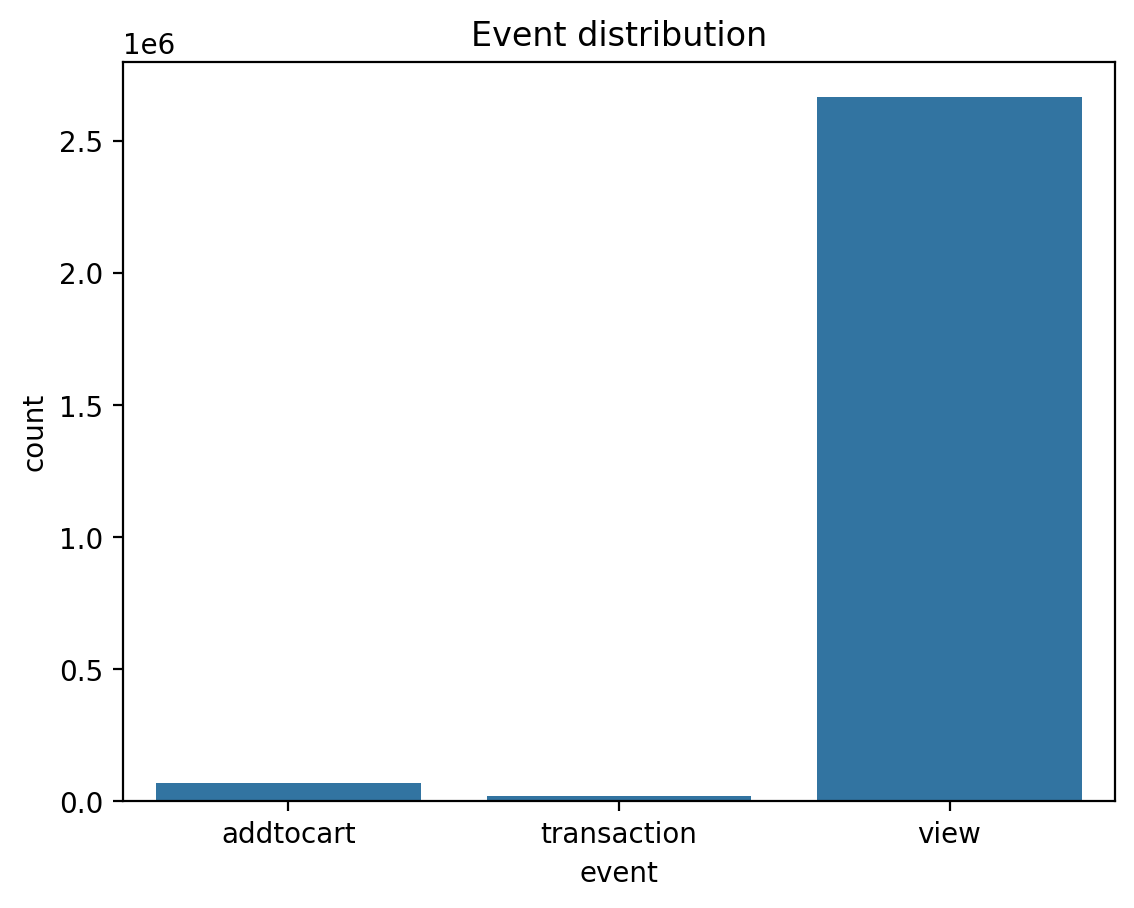

In [30]:
sns.countplot(data=events, x="event")
plt.title("Event distribution")
plt.show()

In [31]:
Вывод:
обычно view >> addtocart >> transaction
сильный дисбаланс

SyntaxError: invalid syntax (788439678.py, line 1)

# 7. Временной анализ

In [ ]:
events["datetime"] = pd.to_datetime(events["timestamp"], unit="ms")

events["date"] = events["datetime"].dt.date
events["hour"] = events["datetime"].dt.hour

## События по времени

In [ ]:
events.groupby("date").size().plot(figsize=(12,4), title="Events over time")
plt.show()

## По часам

In [ ]:
sns.countplot(data=events, x="hour")
plt.title("Events by hour")
plt.show()

Вывод:
пики активности
есть ли сезонность

# 8. Популярные товары

In [ ]:
top_items = events["itemid"].value_counts().head(20)

top_items.plot(kind="bar", figsize=(10,4), title="Top items")
plt.show()

Вывод:
есть сильный popularity bias

# 9. Активность пользователей

In [ ]:
user_activity = events.groupby("visitorid").size()

user_activity.describe()

In [ ]:
sns.histplot(user_activity, bins=50, log_scale=True)
plt.title("User activity distribution")
plt.show()

In [ ]:
Вывод:
большинство пользователей малоактивны
длинный хвост

# 10. Активность товаров

In [ ]:
item_activity = events.groupby("itemid").size()

sns.histplot(item_activity, bins=50, log_scale=True)
plt.title("Item popularity distribution")
plt.show()

In [ ]:
Вывод:
few popular items, many rare

# 11. Конверсия

In [ ]:
events["event"].value_counts(normalize=True)

In [ ]:
Вывод:
низкая конверсия в покупку
add-to-cart — разумный target

# 12. Разреженность (sparsity)

In [ ]:
n_users = events["visitorid"].nunique()
n_items = events["itemid"].nunique()
n_interactions = len(events)

sparsity = 1 - n_interactions / (n_users * n_items)

print("Sparsity:", sparsity)

In [ ]:
Вывод:
обычно ~99%+
значит нужен CF/ALS

# 13. Cold start

In [ ]:
user_counts = events["visitorid"].value_counts()
cold_users = (user_counts == 1).mean()

print("Cold users ratio:", cold_users)

In [ ]:
Вывод:
много новых пользователей
нужен popular fallback

# 14. Анализ item_properties

In [ ]:
item_props["property"].value_counts().head(10)

In [ ]:
item_props["value"].nunique()

In [ ]:
Вывод:
данные разреженные
можно использовать как фичи

# Финальные выводы

In [ ]:
1. Данные имеют сильный дисбаланс: большинство событий — просмотры.
2. Пользовательская активность распределена неравномерно (long tail).
3. Наблюдается сильный popularity bias среди товаров.
4. Матрица user-item сильно разрежена (>99%).
5. Высокая доля cold users → нужен fallback (Top Popular).
6. Добавление в корзину выбрано как целевое действие.
7. Подход к решению:
   - candidate generation (ALS, popularity)
   - ranking (LightGBM)